# EDS 217 Final Project: Team Jaws

Members: Karla Ramos, Olivia Knapp, Ashwin Chockkalingam

[Session Webpage](https://eds-217-essential-python.github.io/course-materials/interactive-sessions/7d_project_kickoff.html)

Date: 09/09/2026

Questions we were interested in:
1. Which countries in this data set have the highest rate of fatal shark attacks? 
2. Are there major differences in the fatal shark attacks based on the sex of the victims?
3. Which Shark species are documented to have the most fatal attacks in the past 20 years?

Findings:
1. The analysis showed that Brasil, Mexico, and New Caladonia have the highest rate of fatal shark attacks. 
2. A majority of the fatal shark attacks happen to male victims. Even with the increase of fatal shark attacks on the victims labled as females, male identifying victims were fatally killed at a higher rate. 


# 1. Import 
We first imported the necessary libraries, then read in the CSV containing our data. The data we chose to analyze is the incident log from the Global Shark Attack File produced by the Shark Research Institute.

In [20]:
# Imported libraries 
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import requests

# Reading in incident log data
def extract_file_id(url):
    """Extract file id from Google Drive Sharing URL."""
    return url.split("/")[-2]

def df_from_gdrive_csv(url):
    """ Get the CSV file from a Google Drive Sharing URL."""
    file_id = extract_file_id(url)
    URL = "https://docs.google.com/uc?export=download"
    session = requests.Session()
    response = session.get(URL, params={"id": file_id}, stream=True)
    return pd.read_csv(response.raw)

# Example of how to use:
# Note: your sharing link will be different, but should look like this:
sharing_url = "https://drive.google.com/file/d/1l_tfSNqmMExOOiJ1CZjXz0Ek2rFoRLwX/view?usp=drive_link"
df = df_from_gdrive_csv(sharing_url)
df.head()

<positron-console-cell-20>:19: DtypeWarning: Columns (0,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,21,22) have mixed types. Specify dtype option on import or set low_memory=False.


,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Unnamed: 245,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,Unnamed: 252,Unnamed: 253,Unnamed: 254
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


# 2. Explore Data
We checked how many rows and columns there were, what each column was, the type of each column, and how many null values there were in each column. 

In [ ]:
# Checking how many columns and rows in the dataset
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39230 entries, 0 to 39229
Columns: 255 entries, Date to Unnamed: 254
dtypes: float64(234), object(21)
memory usage: 76.3+ MB
None


In [ ]:
# Checking what columns were in the dataset (excel causing empty columns)
df.head()

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,...,Unnamed: 245,Unnamed: 246,Unnamed: 247,Unnamed: 248,Unnamed: 249,Unnamed: 250,Unnamed: 251,Unnamed: 252,Unnamed: 253,Unnamed: 254
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
# Checking the type of each columns
df.dtypes

Date             object
Year            float64
Type             object
Country          object
State            object
                 ...   
Unnamed: 250    float64
Unnamed: 251    float64
Unnamed: 252    float64
Unnamed: 253    float64
Unnamed: 254    float64
Length: 255, dtype: object

In [ ]:
# Checking for null values in the dataset
df.isnull().sum()

Date            32113
Year            32115
Type            32131
Country         32163
State           32600
                ...  
Unnamed: 250    39230
Unnamed: 251    39230
Unnamed: 252    39230
Unnamed: 253    39230
Unnamed: 254    39230
Length: 255, dtype: int64

# Steps 3, 4, and 6: Filtering, Cleaning, and Transforming 
Filtered the dataset for the columns we wanted, cleaned the data in the columns, and dropped irrelevant entries.

In [ ]:
# Removing the empty columns in our dataset.
keep_cols = ['Date',
 'Year',
 'Type',
 'Country',
 'State',
 'Location',
 'Activity',
 'Name',
 'Sex',
 'Age',
 'Injury',
 'Fatal Y/N',
 'Time',
 'Species ',
 'Source',
 'href formula',
 'href',
 'Case Number',
 'Case Number.1',
 'original order']
sharks = df[keep_cols].copy()

sharks

,Date,Year,Type,Country,State,Location,Activity,Name,Sex,Age,Injury,Fatal Y/N,Time,Species,Source,href formula,href,Case Number,Case Number.1,original order
0,26th August,2026.0,Unprovoked,USA,Hawaii,"Ala Moana Beach Park, Oah'u",Surfing,Unknown Female,F,?,No injury bump to surfboard,N,1330hrs,Tiger Shark,Keith Cowley: KHON: KITV:,NaN,NaN,NaN,NaN,NaN
1,23rd August,2026.0,Unprovoked,USA,Florida,Boca Grande (island in the keys),Wading on a sandbar,David Daniel,M,43,Bite to foot,N,1700hrs,Large shark,Keith Cowley: Todd Smith: NBC 6: ABC News:,NaN,NaN,NaN,NaN,NaN
2,19th August,2026.0,Provoked,Reunion Island,Saint-Gilles-les-Baines,Outer Reef Roches Noires,Spearfishiong,Male,M,?,No injury,N,?,Bull shark 2.5m (8.2 ft),Todd Smith: Local Report Zinfos 874:,NaN,NaN,NaN,NaN,NaN
3,11th August,2026.0,Provoked,Ireland,Waterford,Ardemore County,Fishing,Sebastian Achim,M,27,Bite to left leg,N,1615hrs,1.5m (5ft) Blue shark,Keith Cowley: David Bargh: Irish Times BBC Met...,NaN,NaN,NaN,NaN,NaN
4,8th August,2026.0,Unprovoked,USA,Maine,Scarborough Beach Park,Operation of Rescue Torpedo,Greg Wilfert,M,71,Bite to rescue torpedo sustained no injury,N,1300hrs,Great White Shark,WGME: CBS News: Keith Cowley,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39225,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39226,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39227,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
39228,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [27]:
# Filtered the dataset to only include data starting fom 2006. 
sharks = sharks[sharks["Year"] >= 2006]
sharks.shape


(2300, 20)

In [28]:
# Checking the nulls again 
print(sharks['Year'].isnull().sum())
print(sharks['Sex'].isnull().sum())
print(sharks['Fatal Y/N'].isnull().sum())
print(sharks['Country'].isnull().sum())
print(sharks['Type'].isnull().sum())

0
70
138
2
14


In [29]:
# Filter Dataset for wanted columns 
sharks_filtered = sharks[['Year', 'Sex', 'Fatal Y/N', 'Country', 'Type']].copy()


In [30]:
# Check for duplicate rows
sharks_filtered.duplicated().sum()

1420

##### A to K

In [ ]:
# Cleaned the strings in the Sex column in order to only get m - male, and f - female
sharks_filtered['Sex'] = sharks_filtered['Sex'].str.strip().str.lower()

# Drop random entries like 'm f' and '?'
sharks_filtered = sharks_filtered[(sharks_filtered['Sex'] == 'm') | (sharks_filtered['Sex'] == 'f')]

In [32]:
# Clean Fatal Y/N - change type to string, lower case, strip empty space
sharks_filtered['Fatal Y/N'] = sharks_filtered['Fatal Y/N'].str.lower().str.strip()
sharks_filtered = sharks_filtered[(sharks_filtered['Fatal Y/N'] == 'n') | (sharks_filtered['Fatal Y/N'] == 'y')]

In [33]:
# Clean Country column - upper case, strip empty space
sharks_filtered['Country'] = sharks_filtered['Country'].str.upper().str.strip()

In [34]:
# Clean Type column - upper case, strip empty space
sharks_filtered['Type'] = sharks_filtered['Type'].str.upper().str.strip()

In [35]:
# Clean Year column - changing year column which was float to integer. 
sharks_filtered['Year'] = sharks_filtered['Year'].astype(int)


# Steps 5, 7, 8, 10. Sort, Aggregate, Grouped and Visualized

## Step 9 Note: We didn't join or reshape the data 

#### 1. What is the relationship between countries and the proportion of fatal attacks? 

In [ ]:
# Checking how many records there are for each country. 
sharks_filtered['Country'].value_counts() 

Country
USA                  991
AUSTRALIA            453
SOUTH AFRICA         101
BAHAMAS               74
NEW ZEALAND           40
                    ... 
VANUATU                1
US VIRGIN ISLANDS      1
CHILE                  1
SOUTH KOREA            1
MALTA                  1
Name: count, Length: 91, dtype: int64

In [37]:

# Only analyzing countries that had more than 30 records 
Countries_Above_30_Count = ['USA', 'AUSTRALIA', 'SOUTH AFRICA', 'BAHAMAS', 'NEW ZEALAND', 'BRAZIL', 'MEXICO', 'NEW CALEDONIA']
sharks_filtered_further = sharks_filtered[sharks_filtered['Country'].isin(Countries_Above_30_Count)].copy()
print(sharks_filtered_further['Country'].value_counts())

# Grouping by the country and getting a total count of Yes and No values for Fatalities. 
sharks_filtered_further = sharks_filtered_further.groupby('Country')['Fatal Y/N'].value_counts().reset_index()
print(sharks_filtered_further)

# Pivoting the table
sharks_wide = sharks_filtered_further.pivot_table(index = 'Country' , columns = 'Fatal Y/N', values = 'count')

# Creating a new column where we calculate the percentage of fatal attacks (fatal attacks/total attacks). 
sharks_wide['Percentage of Fatal Attacks'] = sharks_wide['y'] / (sharks_wide['n'] + sharks_wide['y']) * 100
sharks_wide = sharks_wide.reset_index()

# Creating new column where we count total attacks
sharks_wide['count'] = (sharks_wide['n'] + sharks_wide['y'])
sharks_wide = sharks_wide.sort_values('count', ascending = False)

print(sharks_wide)

Country
USA              991
AUSTRALIA        453
SOUTH AFRICA     101
BAHAMAS           74
NEW ZEALAND       40
BRAZIL            39
MEXICO            35
NEW CALEDONIA     34
Name: count, dtype: int64
          Country Fatal Y/N  count
0       AUSTRALIA         n    401
1       AUSTRALIA         y     52
2         BAHAMAS         n     68
3         BAHAMAS         y      6
4          BRAZIL         n     28
5          BRAZIL         y     11
6          MEXICO         n     24
7          MEXICO         y     11
8   NEW CALEDONIA         n     20
9   NEW CALEDONIA         y     14
10    NEW ZEALAND         n     36
11    NEW ZEALAND         y      4
12   SOUTH AFRICA         n     81
13   SOUTH AFRICA         y     20
14            USA         n    970
15            USA         y     21
Fatal Y/N        Country      n     y  Percentage of Fatal Attacks  count
7                    USA  970.0  21.0                     2.119072  991.0
0              AUSTRALIA  401.0  52.0                  

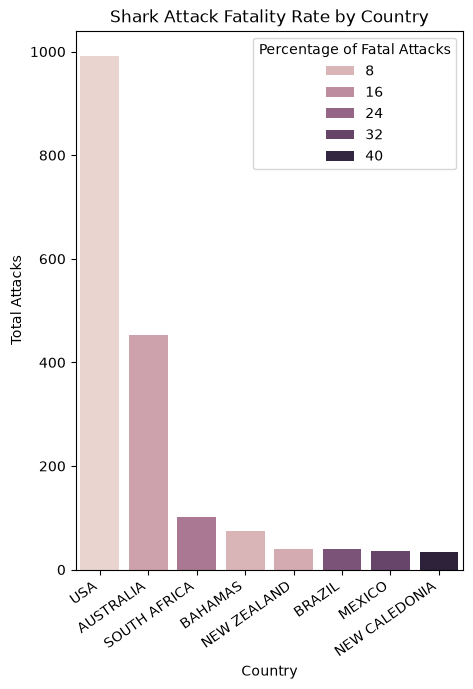

In [40]:
# plotting the graph

plt.figure(figsize = (5,7))
sharks_wide
sns.barplot(data = sharks_wide, x = 'Country', y = 'count', hue = 'Percentage of Fatal Attacks')
plt.xticks(rotation = 35, ha='right')
plt.ylabel('Total Attacks')
plt.xlabel('Country')
plt.title('Shark Attack Fatality Rate by Country')
plt.show()

#### 2.Are there major differences in the fatal shark attacks based on the sex of the victims?


Sex
m    1674
f     417
Name: count, dtype: int64


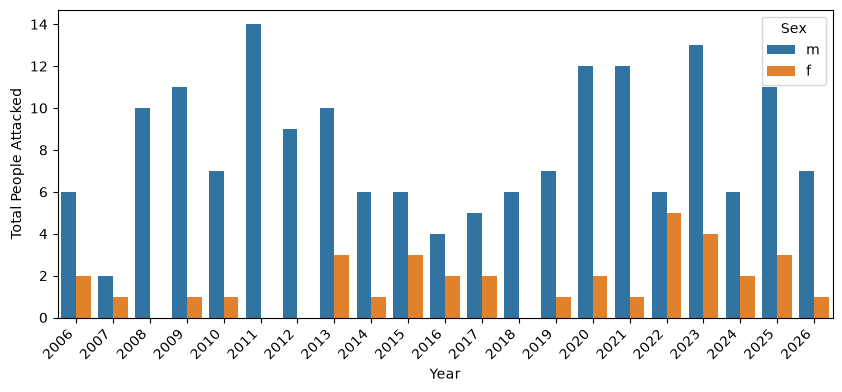

In [42]:
print(sharks_filtered['Sex'].value_counts())

sharks_fatal = sharks_filtered[sharks_filtered['Fatal Y/N'] == "y"] #Filtering for just total fatal attacks
sharks_fatal_year = sharks_fatal.groupby('Year')['Sex'].value_counts().reset_index()
# Groupby Year and Sex
# Resetting index to plot Year on the x-axis

plt.figure(figsize=(10, 4))
sns.barplot(
    data=sharks_fatal_year,
    x="Year", y="count", hue="Sex",
)
plt.xticks(rotation=45, ha='right')
plt.xlabel('Year')
plt.ylabel('Total People Attacked')
plt.show()